# Punjab InSAR → Physics-Aware SWIN3D (Synthetic First)

This notebook follows your requested sequence:
1. Check Punjab GMTSAR time-series products.
2. Inspect and subset W3RA data over the same AOI.
3. Build and validate a synthetic poroelastic forward-model test.
4. Train a physics-aware 3D model scaffold on synthetic data.
5. Prepare transfer to real Punjab inversion (without GRACE for now).

In [3]:
from pathlib import Path
import warnings
import importlib

required = ['numpy','pandas','matplotlib','h5py','xarray','scipy','torch','h5netcdf','netCDF4','geopandas','shapely','pyproj']
missing = []
for m in required:
    try:
        importlib.import_module(m)
    except Exception:
        missing.append(m)

if missing:
    warnings.warn(f'Missing packages: {missing}')
else:
    print('All required imports are available.')

All required imports are available.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import xarray as xr
from scipy.io import whosmat, loadmat

DATA_DIRS = [
    Path('/mnt/data/aoi_punjab_2'),
    Path('/mnt/data/aoi_punjab'),
]
W3RA_DIR = Path('/mnt/data/w3ra_era5_10km_monthly_2003_2024')
OUT_DIR = Path('/home/ubuntu/work/punjab/outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Punjab dirs:')
for d in DATA_DIRS:
    print(' ', d, 'exists=', d.exists())
print('W3RA dir:', W3RA_DIR, 'exists=', W3RA_DIR.exists())

Punjab dirs:
  /mnt/data/aoi_punjab_2 exists= True
  /mnt/data/aoi_punjab exists= True
W3RA dir: /mnt/data/w3ra_era5_10km_monthly_2003_2024 exists= True


In [6]:
def list_h5_datasets(h5_path):
    info = []
    with h5py.File(h5_path, 'r') as f:
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                info.append((name, obj.shape, str(obj.dtype)))
        f.visititems(visitor)
    return info

def pick_first_numeric_dataset(h5_path):
    with h5py.File(h5_path, 'r') as f:
        candidates = []
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset) and np.issubdtype(obj.dtype, np.number):
                candidates.append((name, obj.shape))
        f.visititems(visitor)
        if not candidates:
            return None, None
        candidates = sorted(candidates, key=lambda x: np.prod(x[1]) if len(x[1]) > 0 else 0, reverse=True)
        name, shape = candidates[0]
        data = f[name][()]
    return name, np.array(data)

def read_dates_h5(h5_path):
    if not h5_path.exists():
        return None
    with h5py.File(h5_path, 'r') as f:
        vals = []
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                arr = obj[()]
                vals.append(arr)
        f.visititems(visitor)
    if not vals:
        return None
    arr = np.ravel(np.array(vals[0]))
    out = []
    for v in arr:
        if isinstance(v, (bytes, bytearray)):
            s = v.decode('utf-8', errors='ignore')
        else:
            s = str(v)
        out.append(s)
    dates = pd.to_datetime(pd.Series(out), errors='coerce')
    if dates.notna().sum() == 0:
        return None
    return dates

In [7]:
# Inventory Punjab HDF5 files and inspect dataset schemas
records = []
for d in DATA_DIRS:
    for fn in ['disp_all_ll.h5','coh_ll.h5','vel_ll.h5','aquisition_dates_ll.h5']:
        p = d / fn
        records.append({'dir': str(d), 'file': fn, 'exists': p.exists()})

inv_df = pd.DataFrame(records)
display(inv_df)

for d in DATA_DIRS:
    disp = d / 'disp_all_ll.h5'
    if disp.exists():
        print(f'\n--- {disp} ---')
        for name, shape, dtype in list_h5_datasets(disp)[:20]:
            print(f'  {name}: shape={shape}, dtype={dtype}')

,dir,file,exists
0,/mnt/data/aoi_punjab_2,disp_all_ll.h5,True
1,/mnt/data/aoi_punjab_2,coh_ll.h5,True
2,/mnt/data/aoi_punjab_2,vel_ll.h5,True
3,/mnt/data/aoi_punjab_2,aquisition_dates_ll.h5,True
4,/mnt/data/aoi_punjab,disp_all_ll.h5,True
5,/mnt/data/aoi_punjab,coh_ll.h5,True
6,/mnt/data/aoi_punjab,vel_ll.h5,True
7,/mnt/data/aoi_punjab,aquisition_dates_ll.h5,True



--- /mnt/data/aoi_punjab_2/disp_all_ll.h5 ---
  lat: shape=(1130,), dtype=float64
  lon: shape=(1850,), dtype=float64
  time: shape=(0,), dtype=>f4
  z: shape=(225, 1130, 1850), dtype=float32

--- /mnt/data/aoi_punjab/disp_all_ll.h5 ---
  lat: shape=(1130,), dtype=float64
  lon: shape=(1850,), dtype=float64
  time: shape=(0,), dtype=>f4
  z: shape=(225, 1130, 1850), dtype=float32


Using deformation dataset: z shape= (225, 1130, 1850)


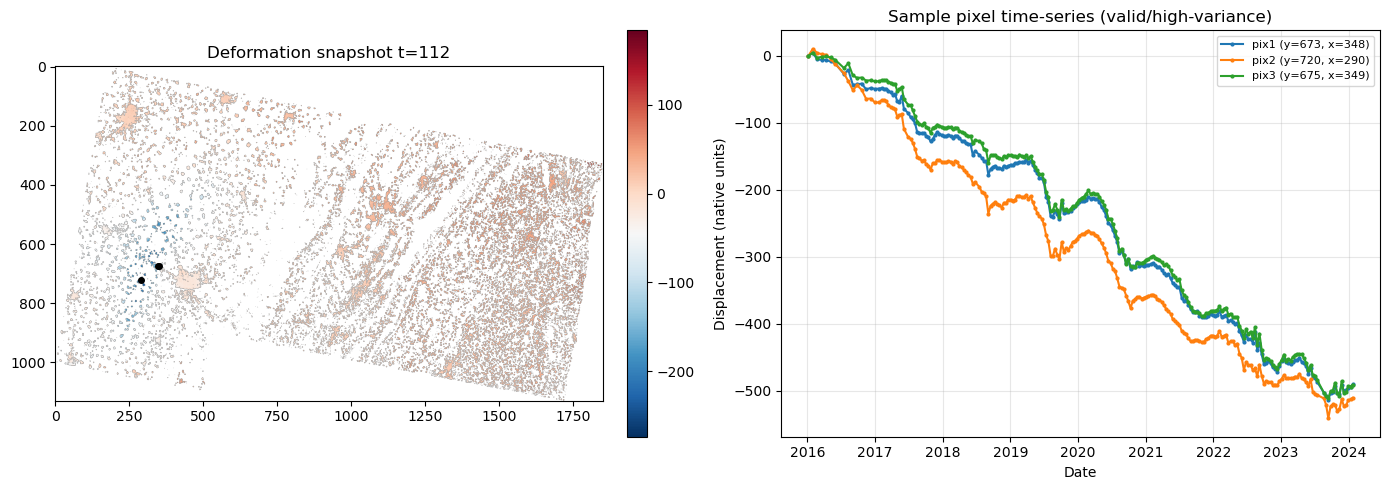

In [8]:
# Plot sample deformation map + robust sample pixel time-series from first available Punjab stack
stack_dir = next((d for d in DATA_DIRS if (d / 'disp_all_ll.h5').exists()), None)
assert stack_dir is not None, 'No Punjab stack with disp_all_ll.h5 found.'

disp_path = stack_dir / 'disp_all_ll.h5'
date_path = stack_dir / 'aquisition_dates_ll.h5'

disp_name, disp = pick_first_numeric_dataset(disp_path)
print('Using deformation dataset:', disp_name, 'shape=', disp.shape)

# Normalize axis order to (T, Y, X) if possible
arr = np.array(disp)
if arr.ndim == 2:
    arr = arr[None, :, :]
elif arr.ndim >= 3:
    if arr.shape[0] < 5 and arr.shape[-1] >= 5:
        arr = np.moveaxis(arr, -1, 0)
    elif arr.shape[0] > arr.shape[-1] and arr.shape[-1] >= 5:
        arr = np.moveaxis(arr, -1, 0)

T, H, W = arr.shape[0], arr.shape[1], arr.shape[2]
dates = read_dates_h5(date_path)
if dates is None or len(dates) < T:
    dates = pd.date_range('2000-01-01', periods=T, freq='12D')

# Compute valid-mask and temporal variance for robust pixel selection
valid_frac = np.mean(np.isfinite(arr), axis=0)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=RuntimeWarning)
    ts_std = np.nanstd(arr, axis=0)
score = np.where(valid_frac > 0.8, ts_std, np.nan)

if np.all(~np.isfinite(score)):
    yx = [(H//2, W//2)]
else:
    flat = np.nan_to_num(score, nan=-np.inf).ravel()
    top_idx = np.argpartition(flat, -3)[-3:]
    yx = [np.unravel_index(i, (H, W)) for i in top_idx]

mid_t = T // 2
fig, ax = plt.subplots(1, 2, figsize=(14,5))
im = ax[0].imshow(arr[mid_t], cmap='RdBu_r')
for y, x in yx:
    ax[0].plot(x, y, 'ko', ms=4)
ax[0].set_title(f'Deformation snapshot t={mid_t}')
plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

for i, (y, x) in enumerate(yx):
    ax[1].plot(dates[:T], arr[:T, y, x], '-o', ms=2, label=f'pix{i+1} (y={y}, x={x})')
ax[1].set_title('Sample pixel time-series (valid/high-variance)')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Displacement (native units)')
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# W3RA inventory and quick schema check (without full loading)
mat_files = sorted(W3RA_DIR.glob('W3RA_ERA5_10km_Monthly_*.mat'))
print('W3RA yearly MAT count:', len(mat_files))
print('First 5 files:')
for p in mat_files[:5]:
    print(' ', p.name)

if mat_files:
    sample = mat_files[len(mat_files)//2]
    print('\nSample MAT schema:', sample.name)
    for name, shape, typ in whosmat(str(sample)):
        print(f'  {name}: shape={shape}, class={typ}')

latlon_mat = W3RA_DIR / 'LatLon_10km.mat'
if latlon_mat.exists():
    print('\nLatLon schema:')
    for name, shape, typ in whosmat(str(latlon_mat)):
        print(f'  {name}: shape={shape}, class={typ}')

W3RA yearly MAT count: 22
First 5 files:
  W3RA_ERA5_10km_Monthly_2003.mat
  W3RA_ERA5_10km_Monthly_2004.mat
  W3RA_ERA5_10km_Monthly_2005.mat
  W3RA_ERA5_10km_Monthly_2006.mat
  W3RA_ERA5_10km_Monthly_2007.mat

Sample MAT schema: W3RA_ERA5_10km_Monthly_2014.mat
  S0_M: shape=(12, 2142930), class=double
  Sd_M: shape=(12, 2142930), class=double
  Sg_M: shape=(12, 2142930), class=double
  Sr_M: shape=(12, 2142930), class=double
  Ss_M: shape=(12, 2142930), class=double
  Ssnow_M: shape=(12, 2142930), class=double
  Stot_M: shape=(12, 2142930), class=double

LatLon schema:
  latitude: shape=(1801, 1), class=double
  longitude: shape=(3600, 1), class=double


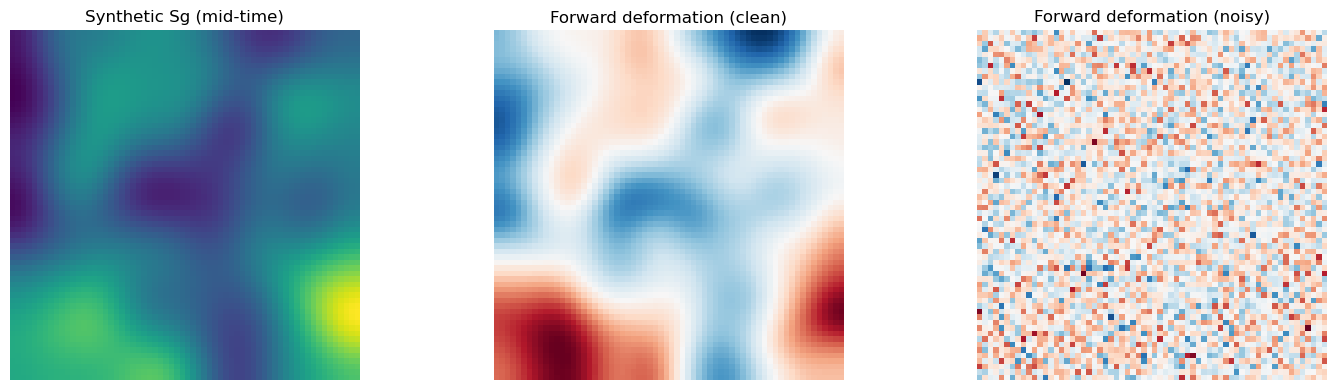

In [10]:
# Synthetic poroelastic forward-model sanity test
# Idea: generate synthetic layered storage anomalies and map them to LOS deformation
# with a Green-like smoothing kernel (proxy for poroelastic response).

from scipy.ndimage import gaussian_filter

rng = np.random.default_rng(42)
T_syn, H_syn, W_syn = 36, 64, 64
t = np.arange(T_syn)

# Synthetic storage layers [T,H,W]
S0 = 10*np.sin(2*np.pi*t[:,None,None]/12) + gaussian_filter(rng.normal(size=(T_syn,H_syn,W_syn)), sigma=(0,3,3))
Ss = 6*np.sin(2*np.pi*(t[:,None,None]-1)/12) + gaussian_filter(rng.normal(size=(T_syn,H_syn,W_syn)), sigma=(0,4,4))
Sd = 3*np.sin(2*np.pi*(t[:,None,None]-2)/12) + gaussian_filter(rng.normal(size=(T_syn,H_syn,W_syn)), sigma=(0,5,5))
Sg = 0.4*t[:,None,None] + 2*np.sin(2*np.pi*(t[:,None,None]-4)/12) + gaussian_filter(rng.normal(size=(T_syn,H_syn,W_syn)), sigma=(0,6,6))

# Layer weights (poroelastic sensitivity proxy)
w = {'S0':0.05, 'Ss':0.10, 'Sd':0.25, 'Sg':0.60}

# Forward operator: weighted sum + Green-like smoothing
disp_syn = (w['S0']*S0 + w['Ss']*Ss + w['Sd']*Sd + w['Sg']*Sg)
for i in range(T_syn):
    disp_syn[i] = gaussian_filter(disp_syn[i], sigma=2.0)

# Add noise
disp_syn_noisy = disp_syn + rng.normal(scale=0.3, size=disp_syn.shape)

fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].imshow(Sg[T_syn//2], cmap='viridis'); ax[0].set_title('Synthetic Sg (mid-time)')
ax[1].imshow(disp_syn[T_syn//2], cmap='RdBu_r'); ax[1].set_title('Forward deformation (clean)')
ax[2].imshow(disp_syn_noisy[T_syn//2], cmap='RdBu_r'); ax[2].set_title('Forward deformation (noisy)')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# Physics-aware synthetic SWIN3D training with strict temporal split (no leakage)
# Predict 4 storage layers from deformation windows and enforce Green-kernel consistency.

from pathlib import Path
import copy
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

EXPECTED_PYTHON = '/home/ubuntu/anaconda3/envs/swin_env/bin/python'
if Path(sys.executable).as_posix() != EXPECTED_PYTHON:
    print(f'[WARN] Expected swin_env interpreter at {EXPECTED_PYTHON}')
    print(f'[WARN] Current interpreter: {sys.executable}')
else:
    print(f'Using swin_env interpreter: {sys.executable}')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

WINDOW_SIZE = 6
BATCH_SIZE = 4
EMBED_DIM = 48
NUM_HEADS = 4
STAGE_DEPTHS = (2, 2, 2)
PATCH_SIZE = (2, 4, 4)
MERGE_SCALE = (1, 2, 2)
LEARNING_RATE = 1e-4
MAX_EPOCHS = 40
PATIENCE = 8
LAMBDA_PHYS = 0.5
LAMBDA_TV = 1e-4
USE_GRACE_LOSS = False  # Hook kept for later; no GRACE supervision in this phase.
LAMBDA_GRACE = 0.0
LAYER_WEIGHTS = (0.05, 0.10, 0.25, 0.60)
GREEN_KERNEL_SIZE = 9
GREEN_SIGMA = 2.0


def build_green_kernel(kernel_size=9, sigma=2.0, device=None, dtype=torch.float32):
    coords = torch.arange(kernel_size, dtype=dtype, device=device) - (kernel_size - 1) / 2
    yy, xx = torch.meshgrid(coords, coords, indexing='ij')
    kernel = torch.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    kernel = kernel / kernel.sum()
    return kernel.view(1, 1, kernel_size, kernel_size)


def anisotropic_total_variation(y_pred):
    dx = torch.abs(y_pred[..., :, 1:] - y_pred[..., :, :-1]).mean()
    dy = torch.abs(y_pred[..., 1:, :] - y_pred[..., :-1, :]).mean()
    return dx + dy


class WindowedSyntheticHydroDataset(Dataset):
    def __init__(self, disp, S0, Ss, Sd, Sg, window_size=6, grace_target=None):
        disp_t = torch.tensor(disp, dtype=torch.float32)
        target_t = torch.tensor(np.stack([S0, Ss, Sd, Sg], axis=1), dtype=torch.float32)

        xs, ys, us, gs = [], [], [], []
        for end_idx in range(window_size - 1, disp_t.shape[0]):
            start_idx = end_idx - window_size + 1
            xs.append(disp_t[start_idx:end_idx + 1].unsqueeze(0))
            ys.append(target_t[end_idx])
            us.append(disp_t[end_idx].unsqueeze(0))
            if grace_target is None:
                gs.append(torch.tensor(float('nan'), dtype=torch.float32))
            else:
                gs.append(torch.tensor(grace_target[end_idx], dtype=torch.float32))

        self.x = torch.stack(xs, dim=0)      # [N,1,T,H,W]
        self.y = torch.stack(ys, dim=0)      # [N,4,H,W]
        self.u_last = torch.stack(us, dim=0) # [N,1,H,W]
        self.grace = torch.stack(gs, dim=0)  # [N]

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.u_last[idx], self.grace[idx]


class PatchEmbed3D(nn.Module):
    def __init__(self, in_channels=1, embed_dim=48, patch_size=(2, 4, 4)):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv3d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x)


class PatchMerging3D(nn.Module):
    def __init__(self, in_dim, out_dim, scale=(1, 2, 2)):
        super().__init__()
        self.reduction = nn.Conv3d(in_dim, out_dim, kernel_size=scale, stride=scale)

    def forward(self, x):
        return self.reduction(x)


class PatchExpand3D(nn.Module):
    def __init__(self, in_dim, out_dim, scale=(1, 2, 2)):
        super().__init__()
        self.expand = nn.ConvTranspose3d(in_dim, out_dim, kernel_size=scale, stride=scale)

    def forward(self, x):
        return self.expand(x)


class SwinBlock3D(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x):
        b, c, t, h, w = x.shape
        tokens = x.reshape(b, c, t * h * w).transpose(1, 2)
        tokens_norm = self.norm1(tokens)
        attn_out, _ = self.attn(tokens_norm, tokens_norm, tokens_norm)
        tokens = tokens + attn_out
        tokens = tokens + self.mlp(self.norm2(tokens))
        return tokens.transpose(1, 2).reshape(b, c, t, h, w)


class SwinStage3D(nn.Module):
    def __init__(self, dim, depth, num_heads):
        super().__init__()
        self.blocks = nn.ModuleList([SwinBlock3D(dim, num_heads=num_heads) for _ in range(depth)])

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x


class SwinUNetPhysicsNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=4, embed_dim=48, num_heads=4, stage_depths=(2, 2, 2), patch_size=(2, 4, 4), merge_scale=(1, 2, 2)):
        super().__init__()
        bottleneck_dim = embed_dim * 2
        self.patch_embed = PatchEmbed3D(in_channels=in_channels, embed_dim=embed_dim, patch_size=patch_size)
        self.encoder = SwinStage3D(embed_dim, depth=stage_depths[0], num_heads=num_heads)
        self.patch_merge = PatchMerging3D(embed_dim, bottleneck_dim, scale=merge_scale)
        self.bottleneck = SwinStage3D(bottleneck_dim, depth=stage_depths[1], num_heads=num_heads)
        self.patch_expand = PatchExpand3D(bottleneck_dim, embed_dim, scale=merge_scale)
        self.skip_fuse = nn.Conv3d(embed_dim * 2, embed_dim, kernel_size=1)
        self.decoder = SwinStage3D(embed_dim, depth=stage_depths[2], num_heads=num_heads)
        self.output_upsample = nn.ConvTranspose3d(embed_dim, embed_dim // 2, kernel_size=patch_size, stride=patch_size)
        self.output_head = nn.Conv3d(embed_dim // 2, out_channels, kernel_size=1)

    def forward(self, x):
        x0 = self.patch_embed(x)
        skip = self.encoder(x0)
        z = self.patch_merge(skip)
        z = self.bottleneck(z)
        z = self.patch_expand(z)

        if z.shape[2:] != skip.shape[2:]:
            z = F.interpolate(z, size=skip.shape[2:], mode='trilinear', align_corners=False)

        z = torch.cat([z, skip], dim=1)
        z = self.skip_fuse(z)
        z = self.decoder(z)
        z = self.output_upsample(z)
        y = self.output_head(z)
        return y[:, :, -1]


def forward_poroelastic_torch(y_pred, weights=LAYER_WEIGHTS, green_kernel=None):
    wv = torch.tensor(weights, dtype=y_pred.dtype, device=y_pred.device).view(1, 4, 1, 1)
    disp = (y_pred * wv).sum(dim=1, keepdim=True)
    kernel = green_kernel
    if kernel is None:
        kernel = build_green_kernel(
            kernel_size=GREEN_KERNEL_SIZE,
            sigma=GREEN_SIGMA,
            device=y_pred.device,
            dtype=y_pred.dtype,
        )
    return F.conv2d(disp, kernel, padding=kernel.shape[-1] // 2)


def compute_grace_loss(y_pred, grace_target, enabled=False):
    if (not enabled) or grace_target is None:
        return y_pred.new_tensor(0.0)

    valid = torch.isfinite(grace_target)
    if not torch.any(valid):
        return y_pred.new_tensor(0.0)

    pred_total = y_pred.sum(dim=1).mean(dim=(1, 2))
    return F.mse_loss(pred_total[valid], grace_target[valid])


def run_epoch(model, loader, optimizer=None, scheduler=None, lambda_phys=0.5, lambda_tv=0.0, lambda_grace=0.0, use_grace=False, green_kernel=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    running = {'loss': 0.0, 'loss_layers': 0.0, 'loss_phys': 0.0, 'loss_tv': 0.0, 'loss_grace': 0.0}
    n = 0

    for xb, yb, ub, gb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        ub = ub.to(device)
        gb = gb.to(device)

        with torch.set_grad_enabled(train_mode):
            yp = model(xb)
            loss_layers = F.mse_loss(yp, yb)
            d_hat = forward_poroelastic_torch(yp, green_kernel=green_kernel)
            loss_phys = F.mse_loss(d_hat, ub)
            loss_tv = anisotropic_total_variation(yp)
            loss_grace = compute_grace_loss(yp, gb, enabled=use_grace)
            loss = loss_layers + lambda_phys * loss_phys + lambda_tv * loss_tv + lambda_grace * loss_grace

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_layers'] += float(loss_layers.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_tv'] += float(loss_tv.item()) * bsz
        running['loss_grace'] += float(loss_grace.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()

    return {k: v / max(n, 1) for k, v in running.items()}


# Build dataset from rolling temporal windows so the 3D model sees short time sequences.
ds = WindowedSyntheticHydroDataset(
    disp=disp_syn_noisy,
    S0=S0,
    Ss=Ss,
    Sd=Sd,
    Sg=Sg,
    window_size=WINDOW_SIZE,
)
N = len(ds)

# Strict chronological split to avoid temporal leakage.
n_train = int(0.70 * N)
n_val = int(0.15 * N)
train_idx = np.arange(0, n_train)
val_idx = np.arange(n_train, n_train + n_val)
test_idx = np.arange(n_train + n_val, N)

train_ds = Subset(ds, train_idx.tolist())
val_ds = Subset(ds, val_idx.tolist())
test_ds = Subset(ds, test_idx.tolist())

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Split sizes -> train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}')
print(f'Windowed input shape: {tuple(ds.x.shape)} | target shape: {tuple(ds.y.shape)}')

model = SwinUNetPhysicsNet3D(
    in_channels=1,
    out_channels=4,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    stage_depths=STAGE_DEPTHS,
    patch_size=PATCH_SIZE,
    merge_scale=MERGE_SCALE,
).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
green_kernel = build_green_kernel(
    kernel_size=GREEN_KERNEL_SIZE,
    sigma=GREEN_SIGMA,
    device=device,
)

best_val = np.inf
wait = 0
best_state = None
history = []

for epoch in range(MAX_EPOCHS):
    tr = run_epoch(
        model,
        train_dl,
        optimizer=opt,
        scheduler=scheduler,
        lambda_phys=LAMBDA_PHYS,
        lambda_tv=LAMBDA_TV,
        lambda_grace=LAMBDA_GRACE,
        use_grace=USE_GRACE_LOSS,
        green_kernel=green_kernel,
    )
    va = run_epoch(
        model,
        val_dl,
        optimizer=None,
        scheduler=None,
        lambda_phys=LAMBDA_PHYS,
        lambda_tv=LAMBDA_TV,
        lambda_grace=LAMBDA_GRACE,
        use_grace=USE_GRACE_LOSS,
        green_kernel=green_kernel,
    )

    history.append({
        'epoch': epoch + 1,
        'lr': float(opt.param_groups[0]['lr']),
        'train_loss': tr['loss'],
        'train_layers': tr['loss_layers'],
        'train_phys': tr['loss_phys'],
        'train_tv': tr['loss_tv'],
        'train_grace': tr['loss_grace'],
        'val_loss': va['loss'],
        'val_layers': va['loss_layers'],
        'val_phys': va['loss_phys'],
        'val_tv': va['loss_tv'],
        'val_grace': va['loss_grace'],
    })

    print(
        f"Epoch {epoch+1:02d} | lr={opt.param_groups[0]['lr']:.2e} | "
        f"train={tr['loss']:.4f} (L={tr['loss_layers']:.4f}, P={tr['loss_phys']:.4f}, TV={tr['loss_tv']:.4f}, G={tr['loss_grace']:.4f}) | "
        f"val={va['loss']:.4f}"
    )

    if va['loss'] < best_val:
        best_val = va['loss']
        wait = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}; best val={best_val:.4f}')
            break

if best_state is not None:
    model.load_state_dict(best_state)

best_model_path = OUT_DIR / 'swin3d_physics_best.pt'
torch.save(model.state_dict(), best_model_path)
print('Saved best model:', best_model_path)

history_df = pd.DataFrame(history)
history_csv = OUT_DIR / 'synthetic_training_history.csv'
history_df.to_csv(history_csv, index=False)
print('Saved training history:', history_csv)

MODEL_ARTIFACTS = {
    'model_name': 'SwinUNetPhysicsNet3D',
    'best_model_path': str(best_model_path),
    'history_csv': str(history_csv),
    'use_grace_loss': USE_GRACE_LOSS,
    'expected_python': EXPECTED_PYTHON,
}


## Next actions

1. Re-run the new SWIN3D synthetic training cell inside `swin_env` and inspect gate metrics.
2. Tune window length, patch size, and physics-loss weights if the synthetic gate still fails.
3. Keep `USE_GRACE_LOSS = False` for now, but wire real GRACE targets into the placeholder hook later if needed.
4. Build a real Punjab loader that standardizes `disp`, `coh`, `vel`, and date vectors.
5. Convert + clip W3RA monthly products to exact Punjab AOI, regrid to the InSAR grid, then fine-tune on Punjab only after the synthetic gate passes.

### Resolved Runnable Spec From The PDF

- Input channels for the synthetic SWIN run: deformation plus `S0`.
- Predicted outputs for the synthetic benchmark: `S0`, `Ss`, `Sd`, `Sg`.
- Training loss for this phase: supervised layer MSE + Green-kernel physics loss + small TV penalty.
- GRACE remains optional and is disabled in this Punjab phase.
- Optimizer/schedule: `AdamW` with cosine decay and early stopping.
- Caveat: the notebook uses a lightweight SWIN-U-Net-style approximation, not a full shifted-window production implementation.


## Implementation block 1: QC export, synthetic gate metrics, and W3RA clipping smoke test

This block operationalizes the immediate implementation tasks in `STEPWISE_PLAN.md`:
1. Export Punjab HDF5 inventory/QC tables.
2. Compute synthetic gate metrics (per-layer RMSE, R2, correlation, forward residual).
3. Run a W3RA AOI clipping smoke test using an InSAR-derived bounding polygon fallback.

In [12]:
# Export Punjab HDF5 inventory and dataset-level QC summary
import json

qc_rows = []
for d in DATA_DIRS:
    for fn in ['disp_all_ll.h5', 'coh_ll.h5', 'vel_ll.h5', 'aquisition_dates_ll.h5']:
        p = d / fn
        row = {
            'stack_dir': str(d),
            'file': fn,
            'exists': bool(p.exists()),
            'datasets': 0,
            'largest_dataset': None,
            'largest_shape': None,
            'largest_dtype': None,
        }
        if p.exists():
            info = list_h5_datasets(p)
            row['datasets'] = len(info)
            if info:
                largest = sorted(info, key=lambda x: np.prod(x[1]) if len(x[1]) > 0 else 0, reverse=True)[0]
                row['largest_dataset'] = largest[0]
                row['largest_shape'] = tuple(int(v) for v in largest[1])
                row['largest_dtype'] = largest[2]
        qc_rows.append(row)

qc_df = pd.DataFrame(qc_rows)
display(qc_df)

qc_csv = OUT_DIR / 'punjab_h5_qc_inventory.csv'
qc_json = OUT_DIR / 'punjab_h5_qc_inventory.json'
qc_df.to_csv(qc_csv, index=False)
qc_json.write_text(json.dumps(qc_rows, indent=2))
print('Saved QC inventory:', qc_csv)
print('Saved QC inventory:', qc_json)

,stack_dir,file,exists,datasets,largest_dataset,largest_shape,largest_dtype
0,/mnt/data/aoi_punjab_2,disp_all_ll.h5,True,4,z,"(225, 1130, 1850)",float32
1,/mnt/data/aoi_punjab_2,coh_ll.h5,True,3,z,"(1130, 1850)",float32
2,/mnt/data/aoi_punjab_2,vel_ll.h5,True,3,z,"(1130, 1850)",float32
3,/mnt/data/aoi_punjab_2,aquisition_dates_ll.h5,True,1,acquisition_dates,"(1, 225)",object
4,/mnt/data/aoi_punjab,disp_all_ll.h5,True,4,z,"(225, 1130, 1850)",float32
5,/mnt/data/aoi_punjab,coh_ll.h5,True,3,z,"(1130, 1850)",float32
6,/mnt/data/aoi_punjab,vel_ll.h5,True,3,z,"(1130, 1850)",float32
7,/mnt/data/aoi_punjab,aquisition_dates_ll.h5,True,1,acquisition_dates,"(1, 225)",object


Saved QC inventory: /home/ubuntu/work/punjab/outputs/punjab_h5_qc_inventory.csv
Saved QC inventory: /home/ubuntu/work/punjab/outputs/punjab_h5_qc_inventory.json


In [ ]:
# Synthetic gate metrics with strict/soft execution modes
import json

def rmse(a, b):
    return float(np.sqrt(np.nanmean((a - b) ** 2)))

def r2_score_np(y_true, y_pred):
    yt = np.asarray(y_true).ravel()
    yp = np.asarray(y_pred).ravel()
    m = np.isfinite(yt) & np.isfinite(yp)
    if m.sum() < 2:
        return np.nan
    yt, yp = yt[m], yp[m]
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    if ss_tot == 0:
        return np.nan
    return float(1.0 - ss_res / ss_tot)

def corr_np(a, b):
    aa = np.asarray(a).ravel()
    bb = np.asarray(b).ravel()
    m = np.isfinite(aa) & np.isfinite(bb)
    if m.sum() < 2:
        return np.nan
    return float(np.corrcoef(aa[m], bb[m])[0, 1])

# Toggle behavior:
# - False: continue notebook execution even if gate fails (useful for diagnostics/plots)
# - True: fail fast on gate failure
STRICT_GATE = False

# Evaluate gate on held-out TEST split only.
model.eval()
with torch.no_grad():
    x_test = ds.x[test_idx].to(device)
    y_test_true = ds.y[test_idx].cpu().numpy()      # [Ntest,4,H,W]
    u_test_true = ds.u_last[test_idx].cpu().numpy() # [Ntest,1,H,W]
    y_test_pred = model(x_test).cpu().numpy()
    d_test_hat = forward_poroelastic_torch(
        torch.tensor(y_test_pred, dtype=torch.float32, device=device),
        green_kernel=green_kernel,
    ).cpu().numpy()[:, 0]

x_test_np = u_test_true[:, 0]

layer_names = ['S0', 'Ss', 'Sd', 'Sg']
metric_rows = []
for i, name in enumerate(layer_names):
    yt = y_test_true[:, i]
    yp = y_test_pred[:, i]
    metric_rows.append({
        'split': 'test',
        'layer': name,
        'rmse': rmse(yt, yp),
        'r2': r2_score_np(yt, yp),
        'corr': corr_np(yt, yp),
    })

forward_resid_rmse = rmse(x_test_np, d_test_hat)
metrics_df = pd.DataFrame(metric_rows)
metrics_df['forward_residual_rmse'] = forward_resid_rmse
metrics_df['model_name'] = MODEL_ARTIFACTS.get('model_name', 'unknown') if 'MODEL_ARTIFACTS' in globals() else 'unknown'
metrics_df['use_grace_loss'] = bool(MODEL_ARTIFACTS.get('use_grace_loss', False)) if 'MODEL_ARTIFACTS' in globals() else False

# Explicit synthetic gate thresholds
GATE = {
    'min_r2': {'S0': 0.40, 'Ss': 0.40, 'Sd': 0.40, 'Sg': 0.70},
    'max_rmse': {'S0': 5.00, 'Ss': 3.50, 'Sd': 2.00, 'Sg': 2.00},
    'min_corr': {'S0': 0.60, 'Ss': 0.60, 'Sd': 0.60, 'Sg': 0.85},
    'max_forward_residual_rmse': 0.80,
}

fails = []
for _, r in metrics_df.iterrows():
    lyr = r['layer']
    if not np.isfinite(r['r2']) or r['r2'] < GATE['min_r2'][lyr]:
        fails.append(f'{lyr}: r2<{GATE["min_r2"][lyr]}')
    if not np.isfinite(r['rmse']) or r['rmse'] > GATE['max_rmse'][lyr]:
        fails.append(f'{lyr}: rmse>{GATE["max_rmse"][lyr]}')
    if not np.isfinite(r['corr']) or r['corr'] < GATE['min_corr'][lyr]:
        fails.append(f'{lyr}: corr<{GATE["min_corr"][lyr]}')

if not np.isfinite(forward_resid_rmse) or forward_resid_rmse > GATE['max_forward_residual_rmse']:
    fails.append(
        f"forward_residual_rmse>{GATE['max_forward_residual_rmse']} (got {forward_resid_rmse:.4f})"
    )

gate_pass = len(fails) == 0
metrics_df['gate_pass'] = gate_pass
display(metrics_df)

metrics_csv = OUT_DIR / 'synthetic_gate_metrics.csv'
metrics_df.to_csv(metrics_csv, index=False)
print('Saved synthetic metrics:', metrics_csv)

gate_json = OUT_DIR / 'synthetic_gate_config.json'
gate_json.write_text(json.dumps(GATE, indent=2))
print('Saved gate config:', gate_json)

report = {
    'gate_pass': gate_pass,
    'strict_gate': STRICT_GATE,
    'failed_checks': fails,
    'model_name': metrics_df['model_name'].iloc[0],
    'use_grace_loss': bool(metrics_df['use_grace_loss'].iloc[0]),
}
report_json = OUT_DIR / 'synthetic_gate_report.json'
report_json.write_text(json.dumps(report, indent=2))
print('Saved gate report:', report_json)

# Expose status to later cells
GATE_STATUS = report

if fails:
    msg = 'SYNTHETIC GATE FAILED: ' + '; '.join(fails)
    if STRICT_GATE:
        raise AssertionError(msg)
    else:
        print('[WARN]', msg)
        print('[WARN] Continuing because STRICT_GATE=False (diagnostic mode).')
else:
    print('SYNTHETIC GATE PASSED')

In [15]:
# W3RA AOI clipping smoke test with strict AOI-source handling
import geopandas as gpd
from shapely.geometry import box
import sys

# Ensure project root is importable when notebook runs from punjab/
if '/home/ubuntu/work' not in sys.path:
    sys.path.append('/home/ubuntu/work')

try:
    from w3ra_synthetic_deformation.w3ra_clip_aoi import clip_w3ra_to_aoi
except Exception as e:
    clip_w3ra_to_aoi = None
    print('Import warning for clip_w3ra_to_aoi:', e)

ALLOW_FALLBACK_AOI = False

# Conservative fallback bbox (only used if explicitly allowed)
fallback_bounds = (29.0, 33.0, 70.0, 76.0)  # lat_min, lat_max, lon_min, lon_max

def find_lat_lon_datasets(h5_path):
    lat_candidates = []
    lon_candidates = []
    with h5py.File(h5_path, 'r') as f:
        def visitor(name, obj):
            if not isinstance(obj, h5py.Dataset):
                return
            lname = name.lower()
            if 'lat' in lname:
                lat_candidates.append(name)
            if 'lon' in lname:
                lon_candidates.append(name)
        f.visititems(visitor)

        # Prefer datasets under common names first
        lat_candidates = sorted(lat_candidates, key=lambda n: (0 if n.endswith('/lat') or n == 'lat' else 1, len(n)))
        lon_candidates = sorted(lon_candidates, key=lambda n: (0 if n.endswith('/lon') or n == 'lon' else 1, len(n)))

        for lat_name in lat_candidates:
            for lon_name in lon_candidates:
                try:
                    lat = np.array(f[lat_name][()])
                    lon = np.array(f[lon_name][()])
                    if lat.size > 0 and lon.size > 0:
                        return lat, lon, lat_name, lon_name
                except Exception:
                    continue
    return None, None, None, None

aoi_source = {
    'source': None,
    'stack_dir': None,
    'lat_dataset': None,
    'lon_dataset': None,
}

lat_min = lat_max = lon_min = lon_max = None

for d in DATA_DIRS:
    disp_file = d / 'disp_all_ll.h5'
    if not disp_file.exists():
        continue

    lat, lon, lat_name, lon_name = find_lat_lon_datasets(disp_file)
    if lat is None or lon is None:
        continue

    lat_min = float(np.nanmin(lat))
    lat_max = float(np.nanmax(lat))
    lon_min = float(np.nanmin(lon))
    lon_max = float(np.nanmax(lon))

    aoi_source.update({
        'source': 'insar_latlon',
        'stack_dir': str(d),
        'lat_dataset': lat_name,
        'lon_dataset': lon_name,
    })
    break

if lat_min is None:
    if not ALLOW_FALLBACK_AOI:
        raise RuntimeError(
            'Could not derive AOI bounds from InSAR lat/lon datasets and fallback AOI is disabled. '
            'Set ALLOW_FALLBACK_AOI=True only if you intentionally want fallback clipping.'
        )
    lat_min, lat_max, lon_min, lon_max = fallback_bounds
    aoi_source.update({
        'source': 'fallback_bbox',
        'stack_dir': None,
        'lat_dataset': None,
        'lon_dataset': None,
    })

geom = box(lon_min, lat_min, lon_max, lat_max)
aoi_gdf = gpd.GeoDataFrame({'name': ['punjab_bbox_fallback']}, geometry=[geom], crs='EPSG:4326')

aoi_geojson = OUT_DIR / 'punjab_bbox_fallback.geojson'
aoi_gdf.to_file(aoi_geojson, driver='GeoJSON')
print('Saved AOI polygon:', aoi_geojson)
print('AOI source:', aoi_source)

aoi_meta_path = OUT_DIR / 'aoi_source_metadata.json'
aoi_meta_path.write_text(json.dumps(aoi_source, indent=2))
print('Saved AOI source metadata:', aoi_meta_path)

if clip_w3ra_to_aoi is None:
    print('Skipping clip smoke test because clip_w3ra_to_aoi import failed.')
else:
    candidate_paths = [OUT_DIR / 'W3RA_punjab_preclipped.nc'] + sorted(W3RA_DIR.glob('*.nc'))
    netcdf_candidates = [p for p in candidate_paths if p.exists()]
    if not netcdf_candidates:
        print('No NetCDF found; run MAT->NetCDF conversion cell before clip test.')
    else:
        w3ra_nc = netcdf_candidates[0]
        print('Running clip smoke test with:', w3ra_nc)
        smoke_nc = OUT_DIR / 'w3ra_clip_smoke_test.nc'
        clipped = clip_w3ra_to_aoi(str(w3ra_nc), str(aoi_geojson), str(smoke_nc))
        print('Clipped dataset dims:', dict(clipped.dims))
        print('Saved clip smoke output:', smoke_nc)

Saved AOI polygon: /home/ubuntu/work/punjab/outputs/punjab_bbox_fallback.geojson
AOI source: {'source': 'insar_latlon', 'stack_dir': '/mnt/data/aoi_punjab_2', 'lat_dataset': 'lat', 'lon_dataset': 'lon'}
Saved AOI source metadata: /home/ubuntu/work/punjab/outputs/aoi_source_metadata.json
Running clip smoke test with: /home/ubuntu/work/punjab/outputs/W3RA_punjab_preclipped.nc
AOI-clipped W3RA written to /home/ubuntu/work/punjab/outputs/w3ra_clip_smoke_test.nc
Clipped dataset dims: {'time': 264, 'lat': 6, 'lon': 13}
Saved clip smoke output: /home/ubuntu/work/punjab/outputs/w3ra_clip_smoke_test.nc


/mnt/data/tmp/ipykernel_1220837/4287396907.py:119: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Clipped dataset dims:', dict(clipped.dims))


In [16]:
# W3RA MAT->NetCDF conversion helper (generic yearly files)
# Note: If Punjab-specific MAT exists, prefer the specialized converter cell below.
import sys
import importlib

if '/home/ubuntu/work' not in sys.path:
    sys.path.append('/home/ubuntu/work')

pinjab_mat = W3RA_DIR / 'Pinjab_W3RA_10km.mat'
if pinjab_mat.exists():
    print('Punjab-specific MAT detected. Skipping generic yearly conversion cell.')
else:
    try:
        import w3ra_mat_2netcdf as w3ra_convert_mod
        importlib.reload(w3ra_convert_mod)
        convert_w3ra_mat_to_netcdf = w3ra_convert_mod.convert_w3ra_mat_to_netcdf
    except Exception as e:
        convert_w3ra_mat_to_netcdf = None
        print('Import warning for convert_w3ra_mat_to_netcdf:', e)

    latlon_file = W3RA_DIR / 'LatLon_10km.mat'
    out_nc = W3RA_DIR / 'W3RA_2003_2024_combined.nc'
    existing_nc = sorted(W3RA_DIR.glob('*.nc'))

    if existing_nc:
        print('NetCDF already present, skipping conversion. Example:', existing_nc[0])
    elif convert_w3ra_mat_to_netcdf is None:
        print('Converter import failed. Cannot run conversion in this notebook yet.')
    elif not latlon_file.exists():
        print('Missing lat/lon file:', latlon_file)
    else:
        print('Starting conversion to:', out_nc)
        convert_w3ra_mat_to_netcdf(str(W3RA_DIR), str(latlon_file), str(out_nc))
        print('Conversion complete:', out_nc)

Punjab-specific MAT detected. Skipping generic yearly conversion cell.


In [17]:
# Diagnose Punjab-specific W3RA MAT assets to select the correct conversion path
from scipy.io import whosmat

special_mats = [
    W3RA_DIR / 'Pinjab_W3RA_10km.mat',
    W3RA_DIR / 'selecti_10k.mat',
    W3RA_DIR / 'LatLon_10km.mat',
]

for p in special_mats:
    print('\nFile:', p.name, 'exists=', p.exists())
    if not p.exists():
        continue
    schema = whosmat(str(p))
    for name, shape, typ in schema[:30]:
        print(f'  {name}: shape={shape}, class={typ}')


File: Pinjab_W3RA_10km.mat exists= True
  S0_pinjab: shape=(264, 1681), class=double
  Sd_pinjab: shape=(264, 1681), class=double
  Sg_pinjab: shape=(264, 1681), class=double
  Sr_pinjab: shape=(264, 1681), class=double
  Ss_pinjab: shape=(264, 1681), class=double
  Ssnow_pinjab: shape=(264, 1681), class=double
  lat_pinjab: shape=(41, 1), class=double
  lon_pinjab: shape=(41, 1), class=double
  selecti_region: shape=(1681, 1), class=double

File: selecti_10k.mat exists= True
  selecti_10k: shape=(2142930, 1), class=double

File: LatLon_10km.mat exists= True
  latitude: shape=(1801, 1), class=double
  longitude: shape=(3600, 1), class=double


In [18]:
# Build Punjab-ready NetCDF from Pinjab_W3RA_10km.mat
from scipy.io import loadmat

pinjab_mat = W3RA_DIR / 'Pinjab_W3RA_10km.mat'
punjab_nc = OUT_DIR / 'W3RA_punjab_preclipped.nc'

if not pinjab_mat.exists():
    print('Missing file:', pinjab_mat)
else:
    m = loadmat(str(pinjab_mat), squeeze_me=True)

    lat = np.asarray(m['lat_pinjab']).reshape(-1)
    lon = np.asarray(m['lon_pinjab']).reshape(-1)
    nlat, nlon = lat.size, lon.size
    npix = nlat * nlon

    var_map = {
        'S0': 'S0_pinjab',
        'Ss': 'Ss_pinjab',
        'Sd': 'Sd_pinjab',
        'Sg': 'Sg_pinjab',
        'Sr': 'Sr_pinjab',
        'Ssnow': 'Ssnow_pinjab',
    }

    data_vars = {}
    t_len = None
    for out_name, src_name in var_map.items():
        if src_name not in m:
            continue
        arr = np.asarray(m[src_name])
        if arr.ndim != 2:
            print('Skipping', src_name, 'unexpected ndim', arr.ndim)
            continue
        if t_len is None:
            t_len = arr.shape[0]
        if arr.shape[1] != npix:
            print('Skipping', src_name, 'pixel mismatch', arr.shape[1], '!=', npix)
            continue
        data_vars[out_name] = (('time', 'lat', 'lon'), arr.reshape(arr.shape[0], nlat, nlon))

    if not data_vars:
        print('No valid Punjab W3RA variables found for NetCDF export.')
    else:
        time = pd.date_range('2003-01-01', periods=t_len, freq='MS')
        ds_punjab = xr.Dataset(data_vars=data_vars, coords={'time': time, 'lat': lat, 'lon': lon})
        ds_punjab.to_netcdf(punjab_nc)
        print('Saved Punjab W3RA NetCDF:', punjab_nc)
        print('Dims:', dict(ds_punjab.dims))

Saved Punjab W3RA NetCDF: /home/ubuntu/work/punjab/outputs/W3RA_punjab_preclipped.nc
Dims: {'time': 264, 'lat': 41, 'lon': 41}


/mnt/data/tmp/ipykernel_1220837/2146462743.py:49: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Dims:', dict(ds_punjab.dims))


## Interactive diagnostics: InSAR, synthetic, and W3RA maps

This block adds lightweight interactive visual diagnostics:
1. Animated map for InSAR time series (spatially/temporally decimated for speed).
2. Animated map for synthetic deformation time series.
3. W3RA layer explorer with layer/time controls and pixel time-series selector.

In [29]:
# Shared helpers for interactive visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import plotly.express as px
except Exception as e:
    px = None
    print('Plotly not available:', e)

try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception as e:
    widgets = None
    print('ipywidgets not available:', e)


def ensure_cube_thw(arr_like, name='cube'):
    """Coerce array to [T,H,W]. Supports [T,H,W], [H,W], [T,P], [P,T] where P is square."""
    a = np.asarray(arr_like)

    if a.ndim == 3:
        return a

    if a.ndim == 2:
        # [H,W] single frame
        if a.shape[0] > 1 and a.shape[1] > 1 and abs(a.shape[0] - a.shape[1]) < max(a.shape) * 0.2:
            return a[None, :, :]

        # [T,P] where P = side^2
        t, p = a.shape
        side = int(np.sqrt(p))
        if side * side == p:
            return a.reshape(t, side, side)

        # [P,T] where P = side^2
        p2, t2 = a.shape
        side2 = int(np.sqrt(p2))
        if side2 * side2 == p2:
            return a.T.reshape(t2, side2, side2)

        raise ValueError(f'{name}: 2D shape {a.shape} is not image-compatible and not square-flattened time series')

    raise ValueError(f'{name}: expected 2D or 3D array, got shape {a.shape}')


def decimate_cube(cube, max_h=220, max_w=220, max_t=120):
    """Downsample a [T,H,W] cube for responsive interactive plotting."""
    c = ensure_cube_thw(cube, name='decimate_cube input')

    t_stride = max(1, int(np.ceil(c.shape[0] / max_t)))
    y_stride = max(1, int(np.ceil(c.shape[1] / max_h)))
    x_stride = max(1, int(np.ceil(c.shape[2] / max_w)))

    c_small = c[::t_stride, ::y_stride, ::x_stride]
    return c_small, t_stride, y_stride, x_stride


def maybe_dates(dates_like, n):
    """Return length-n datetime series, fallback to synthetic index if unavailable."""
    if dates_like is None:
        return pd.Series(pd.date_range('2000-01-01', periods=n, freq='MS'))

    d = pd.to_datetime(pd.Series(dates_like), errors='coerce')
    d = d.dropna().reset_index(drop=True)
    if len(d) >= n:
        return d.iloc[:n].reset_index(drop=True)

    return pd.Series(pd.date_range('2000-01-01', periods=n, freq='MS'))


def interactive_cube_map(cube, dates_like=None, title='Interactive cube', color_scale='RdBu_r'):
    """Create Plotly animated map for a [T,H,W] cube."""
    if px is None:
        print('Install plotly to enable interactive map: pip install plotly')
        return None

    c_small, t_stride, y_stride, x_stride = decimate_cube(cube)
    n = c_small.shape[0]
    d = maybe_dates(dates_like, n)

    vmin = float(np.nanpercentile(c_small, 2))
    vmax = float(np.nanpercentile(c_small, 98))

    fig = px.imshow(
        c_small,
        animation_frame=0,
        color_continuous_scale=color_scale,
        zmin=vmin,
        zmax=vmax,
        aspect='auto',
        labels={'animation_frame': 'time_index', 'color': 'value'}
    )

    for i, fr in enumerate(fig.frames):
        if i < len(d):
            fr.name = str(pd.Timestamp(d.iloc[i]).date())

    if fig.layout.sliders and len(fig.layout.sliders) > 0:
        steps = fig.layout.sliders[0]['steps']
        for i in range(min(len(steps), len(d))):
            steps[i]['label'] = str(pd.Timestamp(d.iloc[i]).date())

    fig.update_layout(
        title=f"{title} (decimated: t/{t_stride}, y/{y_stride}, x/{x_stride})",
        width=900,
        height=500,
    )
    fig.show()
    return fig


def interactive_point_timeseries(cube, dates_like=None, title='Point time series', y0=0, x0=0):
    """Use sliders to inspect pixel time series from [T,H,W] cube."""
    c = ensure_cube_thw(cube, name='interactive_point_timeseries input')
    d = maybe_dates(dates_like, c.shape[0])

    if widgets is None:
        print('ipywidgets not available; showing static point time series at initial index.')
        y0 = int(np.clip(y0, 0, c.shape[1] - 1))
        x0 = int(np.clip(x0, 0, c.shape[2] - 1))
        ts = c[:, y0, x0]
        plt.figure(figsize=(10, 4))
        plt.plot(d, ts, '-o', ms=2)
        plt.title(f'{title} @ (y={y0}, x={x0})')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        return

    y_slider = widgets.IntSlider(value=int(np.clip(y0, 0, c.shape[1] - 1)), min=0, max=c.shape[1] - 1, step=1, description='y')
    x_slider = widgets.IntSlider(value=int(np.clip(x0, 0, c.shape[2] - 1)), min=0, max=c.shape[2] - 1, step=1, description='x')

    out = widgets.Output()

    def _draw(*_):
        with out:
            out.clear_output(wait=True)
            yy, xx = y_slider.value, x_slider.value
            ts = c[:, yy, xx]
            fig, ax = plt.subplots(1, 1, figsize=(10, 4))
            ax.plot(d, ts, '-o', ms=2)
            ax.set_title(f'{title} @ (y={yy}, x={xx})')
            ax.set_xlabel('time')
            ax.set_ylabel('value')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    y_slider.observe(_draw, names='value')
    x_slider.observe(_draw, names='value')
    display(widgets.VBox([widgets.HBox([y_slider, x_slider]), out]))
    _draw()

Plotly not available: No module named 'plotly'


In [32]:
# Interactive maps: InSAR and synthetic deformation

# InSAR cube (from earlier cell). If not in memory, load quickly from first available stack.
if 'arr' not in globals():
    stack_dir_local = next((d for d in DATA_DIRS if (d / 'disp_all_ll.h5').exists()), None)
    if stack_dir_local is None:
        raise RuntimeError('No Punjab stack with disp_all_ll.h5 found for interactive map.')
    disp_name_local, disp_local = pick_first_numeric_dataset(stack_dir_local / 'disp_all_ll.h5')
    arr = np.asarray(disp_local)
    if arr.ndim == 2:
        arr = arr[None, :, :]
    elif arr.ndim >= 3:
        if arr.shape[0] < 5 and arr.shape[-1] >= 5:
            arr = np.moveaxis(arr, -1, 0)
        elif arr.shape[0] > arr.shape[-1] and arr.shape[-1] >= 5:
            arr = np.moveaxis(arr, -1, 0)

if 'dates' not in globals():
    date_path_local = stack_dir_local / 'aquisition_dates_ll.h5'
    dates = read_dates_h5(date_path_local)

print('InSAR cube shape:', np.asarray(arr).shape)
interactive_cube_map(arr, dates_like=dates, title='Punjab InSAR displacement (interactive)', color_scale='RdBu_r')

# Synthetic deformation cube
if 'disp_syn_noisy' in globals():
    syn_dates = pd.date_range('2003-01-01', periods=disp_syn_noisy.shape[0], freq='MS')
    print('Synthetic cube shape:', np.asarray(disp_syn_noisy).shape)
    interactive_cube_map(disp_syn_noisy, dates_like=syn_dates, title='Synthetic deformation (interactive)', color_scale='RdBu_r')
else:
    print('Synthetic cube not found. Run the synthetic forward-model cell first.')

InSAR cube shape: (264, 1681)
Install plotly to enable interactive map: pip install plotly
Synthetic cube shape: (36, 64, 64)
Install plotly to enable interactive map: pip install plotly


In [33]:
# Interactive W3RA layer explorer (map + point time-series)

if 'ds_punjab' not in globals():
    punjab_nc_local = OUT_DIR / 'W3RA_punjab_preclipped.nc'
    if punjab_nc_local.exists():
        ds_punjab = xr.open_dataset(punjab_nc_local)
        print('Loaded dataset:', punjab_nc_local)
    else:
        raise RuntimeError('W3RA dataset not found. Run the Punjab NetCDF export cell first.')

# Candidate layer names in preferred order
preferred_layers = ['S0', 'Ss', 'Sd', 'Sg', 'Sr', 'Ssnow']
available_layers = [v for v in preferred_layers if v in ds_punjab.data_vars]
if not available_layers:
    available_layers = list(ds_punjab.data_vars)

print('Available W3RA layers:', available_layers)

# Animated map for currently selected default layer
def show_w3ra_layer_animation(layer_name):
    da = ds_punjab[layer_name]
    cube = np.asarray(da.values)
    d = pd.to_datetime(ds_punjab['time'].values, errors='coerce')
    interactive_cube_map(cube, dates_like=d, title=f'W3RA {layer_name} (interactive)', color_scale='Viridis')

show_w3ra_layer_animation(available_layers[0])

# Optional widgets for interactive layer + point selector
if widgets is None:
    print('ipywidgets not available; use show_w3ra_layer_animation("Sg") style calls.')
else:
    layer_dd = widgets.Dropdown(options=available_layers, value=available_layers[0], description='Layer')
    y_slider = widgets.IntSlider(value=0, min=0, max=ds_punjab.dims['lat'] - 1, step=1, description='y')
    x_slider = widgets.IntSlider(value=0, min=0, max=ds_punjab.dims['lon'] - 1, step=1, description='x')

    map_out = widgets.Output()
    ts_out = widgets.Output()

    def _draw_layer_map(*_):
        with map_out:
            map_out.clear_output(wait=True)
            lyr = layer_dd.value
            show_w3ra_layer_animation(lyr)

    def _draw_layer_ts(*_):
        with ts_out:
            ts_out.clear_output(wait=True)
            lyr = layer_dd.value
            yy, xx = y_slider.value, x_slider.value
            da = ds_punjab[lyr]
            d = pd.to_datetime(ds_punjab['time'].values, errors='coerce')
            ts = np.asarray(da[:, yy, xx].values)

            fig, ax = plt.subplots(1, 1, figsize=(10, 4))
            ax.plot(d, ts, '-o', ms=2)
            ax.set_title(f'W3RA {lyr} time series @ (y={yy}, x={xx})')
            ax.set_xlabel('time')
            ax.set_ylabel(lyr)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    layer_dd.observe(_draw_layer_map, names='value')
    layer_dd.observe(_draw_layer_ts, names='value')
    y_slider.observe(_draw_layer_ts, names='value')
    x_slider.observe(_draw_layer_ts, names='value')

    display(widgets.VBox([
        widgets.HBox([layer_dd, y_slider, x_slider]),
        map_out,
        ts_out,
    ]))

    _draw_layer_map()
    _draw_layer_ts()

Available W3RA layers: ['S0', 'Ss', 'Sd', 'Sg', 'Sr', 'Ssnow']
Install plotly to enable interactive map: pip install plotly


/mnt/data/tmp/ipykernel_1220837/2273780028.py:33: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  y_slider = widgets.IntSlider(value=0, min=0, max=ds_punjab.dims['lat'] - 1, step=1, description='y')
/mnt/data/tmp/ipykernel_1220837/2273780028.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  x_slider = widgets.IntSlider(value=0, min=0, max=ds_punjab.dims['lon'] - 1, step=1, description='x')


## Synchronized dashboard: InSAR, synthetic, and W3RA

Use one slider to inspect all three products at a matched temporal position. The slider runs on a normalized index so datasets with different lengths can still be compared side-by-side.

In [34]:
# One-slider synchronized dashboard across InSAR, synthetic, and W3RA

# Prepare input cubes
insar_cube = ensure_cube_thw(np.asarray(arr), name='insar_cube') if 'arr' in globals() else None
synthetic_cube = ensure_cube_thw(np.asarray(disp_syn_noisy), name='synthetic_cube') if 'disp_syn_noisy' in globals() else None

if 'ds_punjab' in globals():
    w3ra_ds_local = ds_punjab
else:
    w3ra_nc_local = OUT_DIR / 'W3RA_punjab_preclipped.nc'
    w3ra_ds_local = xr.open_dataset(w3ra_nc_local) if w3ra_nc_local.exists() else None

if insar_cube is None:
    raise RuntimeError('InSAR cube not found. Run the InSAR loading/plot cell first.')
if synthetic_cube is None:
    raise RuntimeError('Synthetic cube not found. Run the synthetic forward-model cell first.')
if w3ra_ds_local is None:
    raise RuntimeError('W3RA dataset not found. Run the W3RA export/load cell first.')

w3ra_layers_pref = ['S0', 'Ss', 'Sd', 'Sg', 'Sr', 'Ssnow']
w3ra_layers = [v for v in w3ra_layers_pref if v in w3ra_ds_local.data_vars]
if not w3ra_layers:
    w3ra_layers = list(w3ra_ds_local.data_vars)

# Dates
insar_dates = maybe_dates(dates if 'dates' in globals() else None, insar_cube.shape[0])
syn_dates = pd.date_range('2003-01-01', periods=synthetic_cube.shape[0], freq='MS')
w3ra_dates = pd.to_datetime(w3ra_ds_local['time'].values, errors='coerce')

# Precompute robust color limits
insar_v = (float(np.nanpercentile(insar_cube, 2)), float(np.nanpercentile(insar_cube, 98)))
syn_v = (float(np.nanpercentile(synthetic_cube, 2)), float(np.nanpercentile(synthetic_cube, 98)))

if widgets is None:
    print('ipywidgets not available; showing static snapshot at normalized position=0.5')
    p = 0.5
    i_idx = min(int(round(p * (insar_cube.shape[0] - 1))), insar_cube.shape[0] - 1)
    s_idx = min(int(round(p * (synthetic_cube.shape[0] - 1))), synthetic_cube.shape[0] - 1)
    w_idx = min(int(round(p * (len(w3ra_dates) - 1))), len(w3ra_dates) - 1)
    lyr = w3ra_layers[0]
    w3ra_map = np.asarray(w3ra_ds_local[lyr].isel(time=w_idx).values)

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    im0 = ax[0].imshow(insar_cube[i_idx], cmap='RdBu_r', vmin=insar_v[0], vmax=insar_v[1])
    ax[0].set_title(f'InSAR t={i_idx} ({pd.Timestamp(insar_dates[i_idx]).date()})')
    plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

    im1 = ax[1].imshow(synthetic_cube[s_idx], cmap='RdBu_r', vmin=syn_v[0], vmax=syn_v[1])
    ax[1].set_title(f'Synthetic t={s_idx} ({pd.Timestamp(syn_dates[s_idx]).date()})')
    plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

    im2 = ax[2].imshow(w3ra_map, cmap='viridis')
    ax[2].set_title(f'W3RA {lyr} t={w_idx} ({pd.Timestamp(w3ra_dates[w_idx]).date()})')
    plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

    for a in ax:
        a.set_xlabel('x')
        a.set_ylabel('y')
    plt.tight_layout()
    plt.show()
else:
    layer_dd = widgets.Dropdown(options=w3ra_layers, value=w3ra_layers[0], description='W3RA layer')
    pos_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description='time pos')
    auto_play = widgets.Play(value=0, min=0, max=100, step=1, interval=200, description='play')
    auto_slider = widgets.IntSlider(value=0, min=0, max=100, step=1, description='anim')
    widgets.jslink((auto_play, 'value'), (auto_slider, 'value'))

    out = widgets.Output()

    def _draw(*_):
        with out:
            out.clear_output(wait=True)
            p = auto_slider.value / 100.0 if auto_slider.value != 0 else pos_slider.value
            p = float(np.clip(p, 0.0, 1.0))

            i_idx = min(int(round(p * (insar_cube.shape[0] - 1))), insar_cube.shape[0] - 1)
            s_idx = min(int(round(p * (synthetic_cube.shape[0] - 1))), synthetic_cube.shape[0] - 1)
            w_idx = min(int(round(p * (len(w3ra_dates) - 1))), len(w3ra_dates) - 1)

            lyr = layer_dd.value
            w3ra_map = np.asarray(w3ra_ds_local[lyr].isel(time=w_idx).values)

            fig, ax = plt.subplots(1, 3, figsize=(16, 5))

            im0 = ax[0].imshow(insar_cube[i_idx], cmap='RdBu_r', vmin=insar_v[0], vmax=insar_v[1])
            ax[0].set_title(f'InSAR t={i_idx} | {pd.Timestamp(insar_dates[i_idx]).date()}')
            plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

            im1 = ax[1].imshow(synthetic_cube[s_idx], cmap='RdBu_r', vmin=syn_v[0], vmax=syn_v[1])
            ax[1].set_title(f'Synthetic t={s_idx} | {pd.Timestamp(syn_dates[s_idx]).date()}')
            plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

            im2 = ax[2].imshow(w3ra_map, cmap='viridis')
            ax[2].set_title(f'W3RA {lyr} t={w_idx} | {pd.Timestamp(w3ra_dates[w_idx]).date()}')
            plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

            for a in ax:
                a.set_xlabel('x')
                a.set_ylabel('y')
            plt.tight_layout()
            plt.show()

    layer_dd.observe(_draw, names='value')
    pos_slider.observe(_draw, names='value')
    auto_slider.observe(_draw, names='value')

    display(widgets.VBox([
        widgets.HBox([layer_dd, pos_slider]),
        widgets.HBox([auto_play, auto_slider]),
        out,
    ]))

    _draw()

## Export synchronized snapshot figures

This block saves side-by-side PNG snapshots for normalized timeline positions (0%, 25%, 50%, 75%, 100%) into `outputs/figures/`.

In [35]:
# Export synchronized snapshots at fixed normalized timeline positions
fig_dir = OUT_DIR / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# Reuse prepared objects from dashboard cell when available
insar_cube_local = ensure_cube_thw(np.asarray(insar_cube), name='insar_cube_local') if 'insar_cube' in globals() else (ensure_cube_thw(np.asarray(arr), name='arr') if 'arr' in globals() else None)
synthetic_cube_local = ensure_cube_thw(np.asarray(synthetic_cube), name='synthetic_cube_local') if 'synthetic_cube' in globals() else (ensure_cube_thw(np.asarray(disp_syn_noisy), name='disp_syn_noisy') if 'disp_syn_noisy' in globals() else None)

if 'w3ra_ds_local' in globals():
    w3ra_ds_export = w3ra_ds_local
elif 'ds_punjab' in globals():
    w3ra_ds_export = ds_punjab
else:
    nc = OUT_DIR / 'W3RA_punjab_preclipped.nc'
    w3ra_ds_export = xr.open_dataset(nc) if nc.exists() else None

if insar_cube_local is None:
    raise RuntimeError('InSAR cube is unavailable for export.')
if synthetic_cube_local is None:
    raise RuntimeError('Synthetic cube is unavailable for export.')
if w3ra_ds_export is None:
    raise RuntimeError('W3RA dataset is unavailable for export.')

w3ra_layer_export = 'Sg' if 'Sg' in w3ra_ds_export.data_vars else list(w3ra_ds_export.data_vars)[0]

insar_dates_local = maybe_dates(dates if 'dates' in globals() else None, insar_cube_local.shape[0])
syn_dates_local = pd.date_range('2003-01-01', periods=synthetic_cube_local.shape[0], freq='MS')
w3ra_dates_local = pd.to_datetime(w3ra_ds_export['time'].values, errors='coerce')

insar_v = (float(np.nanpercentile(insar_cube_local, 2)), float(np.nanpercentile(insar_cube_local, 98)))
syn_v = (float(np.nanpercentile(synthetic_cube_local, 2)), float(np.nanpercentile(synthetic_cube_local, 98)))

positions = [0.00, 0.25, 0.50, 0.75, 1.00]
saved = []

for p in positions:
    i_idx = min(int(round(p * (insar_cube_local.shape[0] - 1))), insar_cube_local.shape[0] - 1)
    s_idx = min(int(round(p * (synthetic_cube_local.shape[0] - 1))), synthetic_cube_local.shape[0] - 1)
    w_idx = min(int(round(p * (len(w3ra_dates_local) - 1))), len(w3ra_dates_local) - 1)

    w3ra_map = np.asarray(w3ra_ds_export[w3ra_layer_export].isel(time=w_idx).values)

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))

    im0 = ax[0].imshow(insar_cube_local[i_idx], cmap='RdBu_r', vmin=insar_v[0], vmax=insar_v[1])
    ax[0].set_title(f'InSAR t={i_idx} | {pd.Timestamp(insar_dates_local[i_idx]).date()}')
    plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

    im1 = ax[1].imshow(synthetic_cube_local[s_idx], cmap='RdBu_r', vmin=syn_v[0], vmax=syn_v[1])
    ax[1].set_title(f'Synthetic t={s_idx} | {pd.Timestamp(syn_dates_local[s_idx]).date()}')
    plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

    im2 = ax[2].imshow(w3ra_map, cmap='viridis')
    ax[2].set_title(f'W3RA {w3ra_layer_export} t={w_idx} | {pd.Timestamp(w3ra_dates_local[w_idx]).date()}')
    plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

    for a in ax:
        a.set_xlabel('x')
        a.set_ylabel('y')

    pct = int(round(100 * p))
    out_png = fig_dir / f'sync_dashboard_{pct:03d}pct.png'
    plt.tight_layout()
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.close(fig)
    saved.append(str(out_png))

print('Saved synchronized snapshots:')
for s in saved:
    print(' -', s)

Saved synchronized snapshots:
 - /home/ubuntu/work/punjab/outputs/figures/sync_dashboard_000pct.png
 - /home/ubuntu/work/punjab/outputs/figures/sync_dashboard_025pct.png
 - /home/ubuntu/work/punjab/outputs/figures/sync_dashboard_050pct.png
 - /home/ubuntu/work/punjab/outputs/figures/sync_dashboard_075pct.png
 - /home/ubuntu/work/punjab/outputs/figures/sync_dashboard_100pct.png
